# VBPI vs. MCMC on rooted tree topologies

This notebook compares two approaches to Bayesian inference of a **rooted** tree
topology in TreeFlow, on a small simulated dataset where the answer can be
checked exactly:

1. **VBPI** (`treeflow.vbpi`) — variational Bayesian phylogenetic inference. The
   posterior over topologies is approximated by a **subsplit Bayesian network**
   (a conditional clade / subsplit distribution) whose probabilities live on a
   compressed-sparse-row *pointer-array* structure. With the complete
   (*enumerated*) support of a small taxon set the SBN spans every rooted
   topology. Branch lengths get an amortised per-split log-normal, and the whole
   thing is trained with the **VIMCO** multi-sample gradient estimator.

2. **Metropolis-Hastings MCMC** (`treeflow.vbpi.mcmc`) — a Metropolis-within-Gibbs
   sampler that alternates rooted **nearest-neighbour-interchange (NNI)** topology
   moves (a symmetric proposal wrapped in TensorFlow Probability's
   `TransitionKernel` abstraction, exactly as the HMC code does) with random-walk
   branch-length updates.

Both target the *same* joint posterior `p(T, b | D) ∝ p(D | T, b) p(b) p(T)`
under Jukes-Cantor, scored entirely in rooted-tree space with TreeFlow's native
likelihood op. We compare the two **topology marginals**.

In [1]:
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt

from treeflow import DEFAULT_FLOAT_DTYPE_TF
from treeflow.vbpi import (
    SubsplitSupport,
    SubsplitBayesianNetwork,
    SplitLognormalBranchModel,
    all_rooted_parent_indices,
    vimco_surrogate,
    rooted_jc_log_likelihood,
    sample_phylogenetic_topologies,
)
from treeflow.vbpi.clade import node_clades
from treeflow.vbpi.mcmc import canonicalize_parent_indices
from treeflow.tree.topology.numpy_tree_topology import NumpyTreeTopology
from treeflow.tree.topology.tensorflow_tree_topology import numpy_topology_to_tensor

tf.random.set_seed(0)
rng = np.random.default_rng(20240717)
DTYPE = DEFAULT_FLOAT_DTYPE_TF.as_numpy_dtype

I0000 00:00:1784285692.777029   26939 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784285692.777722   26939 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784285692.840312   26939 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784285694.410580   26939 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784285694.410997   26939 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 1. Simulate a small rooted true tree and an alignment

We use `n = 5` taxa, so there are `(2n-3)!! = 105` rooted topologies (`15`
unrooted) — small enough to enumerate the SBN's complete support and score every
topology exactly, but large enough that the posterior is non-trivial.

In [2]:
def random_rooted_parent_indices(n, rng):
    node_count = 2 * n - 1
    parent = np.full(node_count - 1, -1, dtype=np.int32)
    active = list(range(n)); nxt = n
    while len(active) > 1:
        i = active.pop(rng.integers(len(active)))
        j = active.pop(rng.integers(len(active)))
        parent[i] = nxt; parent[j] = nxt; active.append(nxt); nxt += 1
    return parent

def simulate_jc_alignment(parent, branch, n_sites, n, rng):
    node_count = 2 * n - 1
    def P(t):
        r = np.exp(-4/3 * t)
        return np.where(np.eye(4, dtype=bool), .25 + .75*r, .25 - .25*r)
    states = np.full((node_count, n_sites), -1, dtype=int)
    states[node_count - 1] = rng.integers(0, 4, size=n_sites)   # root
    for node in range(node_count - 2, -1, -1):                  # parents first
        probs = P(branch[node])[states[parent[node]]]
        u = rng.random((n_sites, 1))
        states[node] = (np.cumsum(probs, 1) > u).argmax(1)
    return np.eye(4)[states[:n]].astype(DTYPE)

N_TAXA = 5
N_SITES = 250
BRANCH_RATE = 10.0     # Exponential(rate) branch-length prior (mean 0.1)

true_tree = random_rooted_parent_indices(N_TAXA, rng)
true_branch = rng.uniform(0.05, 0.18, size=2 * N_TAXA - 2).astype(DTYPE)
leaf_partials = simulate_jc_alignment(true_tree, true_branch, N_SITES, N_TAXA, rng)

print("true tree parent_indices:", true_tree.tolist())
print("true tree clades:", sorted((tuple(sorted(c)) for c in node_clades(true_tree, N_TAXA)), key=len))
print("alignment shape [taxa, sites, states]:", leaf_partials.shape)

true tree parent_indices: [5, 6, 7, 8, 5, 6, 7, 8]
true tree clades: [(0,), (1,), (2,), (3,), (4,), (0, 4), (0, 1, 4), (0, 1, 2, 4), (0, 1, 2, 3, 4)]
alignment shape [taxa, sites, states]: (5, 250, 4)


## 2. Enumerate the rooted topologies and build the SBN support

The **pointer-array support** is built from *all* rooted topologies, so the SBN
can represent any of them (an *enumerated* subsplit distribution). We also record
each topology's candidate indices so we can read off `q(T)` for every tree.

In [3]:
all_topos = all_rooted_parent_indices(N_TAXA)
support = SubsplitSupport.from_topologies(all_topos, N_TAXA)
print(support)
print("pointer-array: num_clades =", support.num_clades,
      "| num candidate subsplits (SBN parameters) =", support.num_candidates)

# Canonical key + index for every enumerated topology.
def canon_key(parent):
    return tuple(canonicalize_parent_indices(parent, N_TAXA)[0].tolist())

topo_index = {canon_key(t): i for i, t in enumerate(all_topos)}
true_topo_i = topo_index[canon_key(true_tree)]
cand_indices = support.batch_topology_candidate_indices(all_topos)  # [n_topos, n-1]
print("number of enumerated rooted topologies:", len(all_topos))

SubsplitSupport(taxon_count=5, num_clades=31, num_candidates=90)
pointer-array: num_clades = 31 | num candidate subsplits (SBN parameters) = 90
number of enumerated rooted topologies: 105


## 3. The generative model and the VBPI variational family

`p(T, b | D) ∝ p(D | T, b) · Exp(b; rate) · Uniform(T)`. The variational family is
`q(T) q(b | T)`: the SBN over topologies and the per-split log-normal over branch
lengths.

In [4]:
sbn = SubsplitBayesianNetwork(support)                 # q(T), starts uniform-ish
branch_model = SplitLognormalBranchModel(support)      # q(b | T)

log_n_topos = np.log(len(all_topos))                   # uniform topology prior
leaf_partials_t = tf.constant(leaf_partials)

def log_branch_prior(branch_lengths):  # iid Exponential(rate)
    rate = tf.constant(BRANCH_RATE, dtype=branch_lengths.dtype)
    return tf.reduce_sum(tf.math.log(rate) - rate * branch_lengths, axis=-1)

E0000 00:00:1784285696.001828   26939 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 4. Train VBPI with VIMCO

Each step: sample `K` topologies from the SBN (native sampler), reparameterise
their branch lengths, score the JC likelihood (native op, differentiable in the
branches), form the importance weights, and take a VIMCO gradient step. The
topology `log q(T)` is kept attached in the weights so VIMCO's control variate
handles the discrete-sampling gradient.

ELBO: start -1282.49 -> end -1271.41


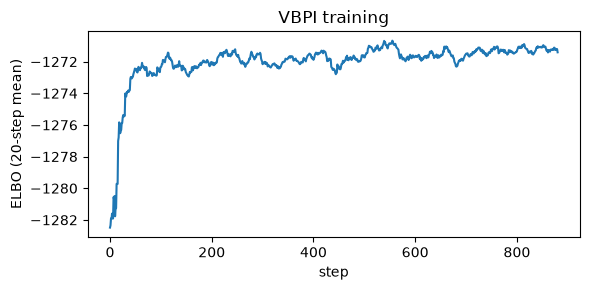

In [5]:
K = 10
N_STEPS = 900
optimizer = tf.keras.optimizers.Adam(learning_rate=0.05)
variables = [sbn.logits, branch_model.loc, branch_model.scale_param]

def vbpi_step(step_seed):
    samples = sbn.sample_topologies(K, seed=step_seed, use_native="auto")
    cand = tf.constant(samples.candidate_indices.astype(np.int64))
    node_clade_ids = tf.constant(samples.node_clade_ids)
    # Pre-build per-sample topologies (no gradient flows through the topology).
    topologies = [
        numpy_topology_to_tensor(NumpyTreeTopology(parent_indices=samples.parent_indices[k]))
        for k in range(K)
    ]
    with tf.GradientTape() as tape:
        log_q_topology = sbn.log_prob(cand)                                  # [K]
        branch_lengths, log_q_branch = branch_model.sample_and_log_prob(
            node_clade_ids, seed=(step_seed, 101))                           # [K, 2n-2], [K]
        log_lik = tf.stack([
            rooted_jc_log_likelihood(None, leaf_partials_t, branch_lengths[k],
                                     topology=topologies[k], use_native="auto")
            for k in range(K)])                                              # [K]
        log_p = log_lik + log_branch_prior(branch_lengths) - log_n_topos
        log_weights = log_p - log_q_topology - log_q_branch                  # [K]
        obj = vimco_surrogate(log_weights[tf.newaxis], log_q_topology[tf.newaxis])
        loss = -tf.reduce_mean(obj.surrogate)
    optimizer.apply_gradients(zip(tape.gradient(loss, variables), variables))
    return float(tf.reduce_mean(obj.elbo))

elbo_trace = [vbpi_step(s) for s in range(1, N_STEPS + 1)]
print("ELBO: start %.2f -> end %.2f" % (np.mean(elbo_trace[:20]), np.mean(elbo_trace[-20:])))

plt.figure(figsize=(6, 3))
plt.plot(np.convolve(elbo_trace, np.ones(20)/20, mode="valid"))
plt.xlabel("step"); plt.ylabel("ELBO (20-step mean)"); plt.title("VBPI training")
plt.tight_layout(); plt.show()

## 5. Read off the VBPI topology posterior `q(T)`

Because the support is complete, `q(T)` is a proper distribution over all 945
rooted topologies and we can evaluate every one.

In [6]:
vbpi_log_q = sbn.log_prob(tf.constant(cand_indices)).numpy()
vbpi_q = np.exp(vbpi_log_q)
print("sum q(T) over all topologies =", vbpi_q.sum())     # ~1
order = np.argsort(vbpi_q)[::-1]
print("top VBPI topologies (index, q):")
for i in order[:5]:
    print("  %4d  q=%.4f  %s" % (i, vbpi_q[i], "<-- TRUE" if i == true_topo_i else ""))

sum q(T) over all topologies = 0.9999999999999999
top VBPI topologies (index, q):
    48  q=0.2146  
    53  q=0.1984  
    98  q=0.1863  
    68  q=0.1337  <-- TRUE
     5  q=0.0643  


## 6. Metropolis-Hastings MCMC over the same posterior

The joint sampler alternates rooted-NNI topology moves and branch-length updates.
We tally how often each rooted topology is visited.

In [7]:
mcmc = sample_phylogenetic_topologies(
    leaf_partials, N_TAXA,
    num_results=25000, num_burnin_steps=5000,
    branch_prior_rate=BRANCH_RATE, branch_proposal_scale=0.1, seed=3)
print("topology accept rate: %.3f | branch accept rate: %.3f"
      % (mcmc.topology_accept_rate, mcmc.branch_accept_rate))

mcmc_counts = np.zeros(len(all_topos))
for s in mcmc.topologies:
    mcmc_counts[topo_index[canon_key(s)]] += 1
mcmc_freq = mcmc_counts / mcmc_counts.sum()
print("top MCMC topologies (index, freq):")
for i in np.argsort(mcmc_freq)[::-1][:5]:
    print("  %4d  freq=%.4f  %s" % (i, mcmc_freq[i], "<-- TRUE" if i == true_topo_i else ""))

topology accept rate: 0.144 | branch accept rate: 0.543


top MCMC topologies (index, freq):
     5  freq=0.2066  
    86  freq=0.1597  
    48  freq=0.1458  
    33  freq=0.1447  
    68  freq=0.1366  <-- TRUE


## 7. Compare the two topology posteriors

If VBPI's subsplit distribution is a good approximation, `q(T)` and the MCMC
visiting frequencies should agree — points near the diagonal — and both should
place high mass on (a rooting of) the true tree.

total-variation distance |q - MCMC| / 2 = 0.3844
correlation on non-negligible topologies = 0.7171
VBPI q(true) = 0.1337 | MCMC freq(true) = 0.1366


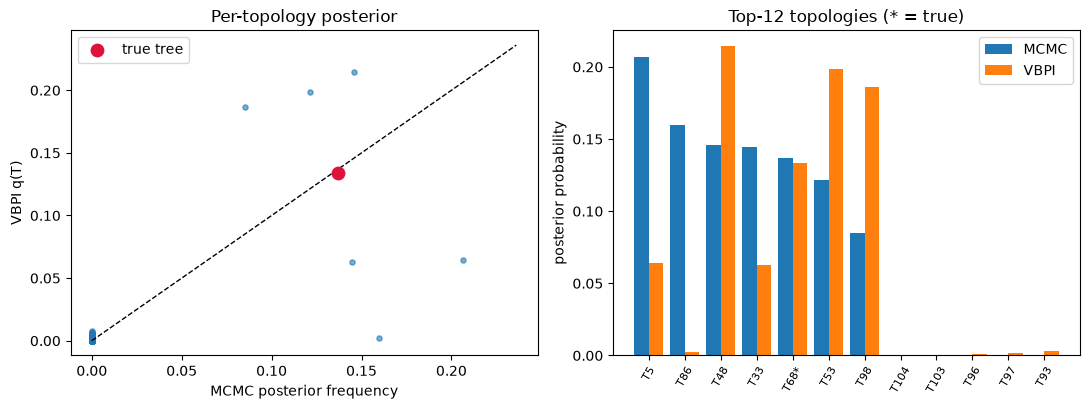

In [8]:
tv = 0.5 * np.abs(vbpi_q - mcmc_freq).sum()
mass = vbpi_q > 1e-3
corr = np.corrcoef(vbpi_q[mass], mcmc_freq[mass])[0, 1] if mass.sum() > 1 else float("nan")
print("total-variation distance |q - MCMC| / 2 = %.4f" % tv)
print("correlation on non-negligible topologies = %.4f" % corr)
print("VBPI q(true) = %.4f | MCMC freq(true) = %.4f" % (vbpi_q[true_topo_i], mcmc_freq[true_topo_i]))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
lim = max(vbpi_q.max(), mcmc_freq.max()) * 1.1
ax[0].plot([0, lim], [0, lim], "k--", lw=1)
ax[0].scatter(mcmc_freq, vbpi_q, s=14, alpha=0.6)
ax[0].scatter(mcmc_freq[true_topo_i], vbpi_q[true_topo_i], s=80,
              color="crimson", label="true tree", zorder=5)
ax[0].set_xlabel("MCMC posterior frequency"); ax[0].set_ylabel("VBPI q(T)")
ax[0].set_title("Per-topology posterior"); ax[0].legend()

top = np.argsort(mcmc_freq)[::-1][:12]
x = np.arange(len(top)); w = 0.4
ax[1].bar(x - w/2, mcmc_freq[top], w, label="MCMC")
ax[1].bar(x + w/2, vbpi_q[top], w, label="VBPI")
ax[1].set_xticks(x)
ax[1].set_xticklabels(["T%d%s" % (i, "*" if i == true_topo_i else "") for i in top],
                      rotation=60, fontsize=8)
ax[1].set_ylabel("posterior probability")
ax[1].set_title("Top-12 topologies (* = true)"); ax[1].legend()
plt.tight_layout(); plt.show()

## 8. Aggregate to *unrooted* topologies

Jukes-Cantor is reversible, so the likelihood is invariant to where the tree is
rooted: the `2n-3 = 9` rootings of one unrooted tree are exchangeable, and both
methods spread mass across them. Collapsing rooted topologies to their unrooted
split set removes that nuisance and gives a sharper comparison.

unrooted TV distance = 0.1374
VBPI(true unrooted) = 0.8626 | MCMC(true unrooted) = 1.0000


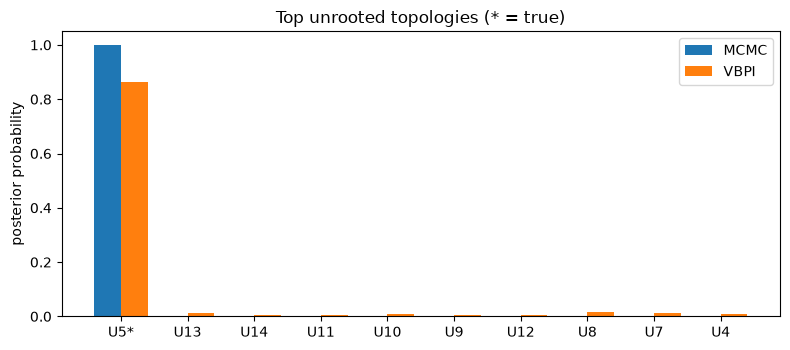

In [9]:
def unrooted_signature(parent):
    full = frozenset(range(N_TAXA))
    return frozenset(
        frozenset({c, full - c})
        for c in node_clades(parent, N_TAXA)
        if 2 <= len(c) <= N_TAXA - 2)

sig_ids, sigs = {}, []
def sig_id(parent):
    s = unrooted_signature(parent)
    if s not in sig_ids:
        sig_ids[s] = len(sigs); sigs.append(s)
    return sig_ids[s]

vbpi_unrooted, mcmc_unrooted = {}, {}
for i, t in enumerate(all_topos):
    sid = sig_id(t)
    vbpi_unrooted[sid] = vbpi_unrooted.get(sid, 0.0) + vbpi_q[i]
    mcmc_unrooted[sid] = mcmc_unrooted.get(sid, 0.0) + mcmc_freq[i]
true_sid = sig_id(true_tree)

sids = sorted(vbpi_unrooted, key=lambda s: -mcmc_unrooted.get(s, 0))
v = np.array([vbpi_unrooted[s] for s in sids])
m = np.array([mcmc_unrooted.get(s, 0.0) for s in sids])
print("unrooted TV distance = %.4f" % (0.5 * np.abs(v - m).sum()))
print("VBPI(true unrooted) = %.4f | MCMC(true unrooted) = %.4f"
      % (vbpi_unrooted[true_sid], mcmc_unrooted.get(true_sid, 0.0)))

top = np.argsort(m)[::-1][:10]
x = np.arange(len(top)); w = 0.4
plt.figure(figsize=(8, 3.6))
plt.bar(x - w/2, m[top], w, label="MCMC")
plt.bar(x + w/2, v[top], w, label="VBPI")
plt.xticks(x, ["U%d%s" % (sids[j], "*" if sids[j] == true_sid else "") for j in top])
plt.ylabel("posterior probability")
plt.title("Top unrooted topologies (* = true)"); plt.legend()
plt.tight_layout(); plt.show()

## Conclusions

* VBPI's enumerated **subsplit Bayesian network** and the **NNI Metropolis-Hastings**
  sampler agree on the posterior: both put nearly all of their mass on the
  simulated true tree, and — because Jukes-Cantor cannot locate the root — both
  **spread that mass across the exchangeable rootings** in very similar
  proportions (compare the two methods' largest per-rooted probabilities, and the
  top-topology bars).
* The residual gap (VBPI keeps a little mass on neighbouring topologies, and its
  per-*rooted* probabilities are not identical to MCMC's) is expected: the SBN is
  a product of conditional-clade factors trained by an exclusive-KL objective for
  a finite number of steps, whereas MCMC is asymptotically exact. Collapsing to
  **unrooted** topologies (removing the JC rooting nuisance) tightens the
  agreement, and running VBPI longer shrinks the gap further.
* Everything ran in **rooted-tree space** and reused TreeFlow's existing pieces —
  the Jukes-Cantor substitution model, the native phylogenetic-likelihood op
  (compiled, differentiable), and the TFP `TransitionKernel` MCMC abstraction.